In [1]:
import yfinance as yt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [8]:
df = yt.download("GOOGL", start="2017-01-01")

[*********************100%***********************]  1 of 1 completed


In [9]:
df.head(5)

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2017-01-03,40.019688,40.189568,39.468929,39.653668,39180000
2017-01-04,40.007797,40.288131,39.826524,40.112797,30306000
2017-01-05,40.267826,40.303486,39.916173,39.994427,26810000
2017-01-06,40.871582,41.057315,40.192542,40.365397,40342000
2017-01-09,40.969162,41.130129,40.693782,40.929043,28178000


In [14]:
df.columns = df.columns.get_level_values(0)

In [15]:
df.sample(5)

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-04-01,54.585579,55.938704,54.159137,55.670259,51970000
2025-08-11,200.299484,200.777807,198.376218,200.239696,25832400
2019-05-16,58.666744,59.145193,57.871811,58.039711,35308000
2018-12-13,53.171036,53.908026,52.747568,53.276534,24986000
2020-09-21,70.832977,71.324297,69.472918,70.906277,56908000


<Axes: xlabel='Date'>

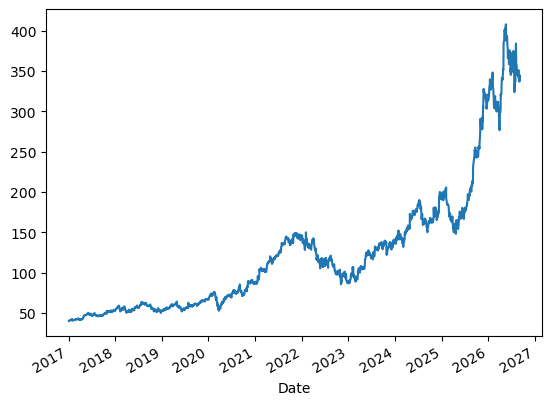

In [17]:
df['High'].plot()

<Axes: xlabel='Date'>

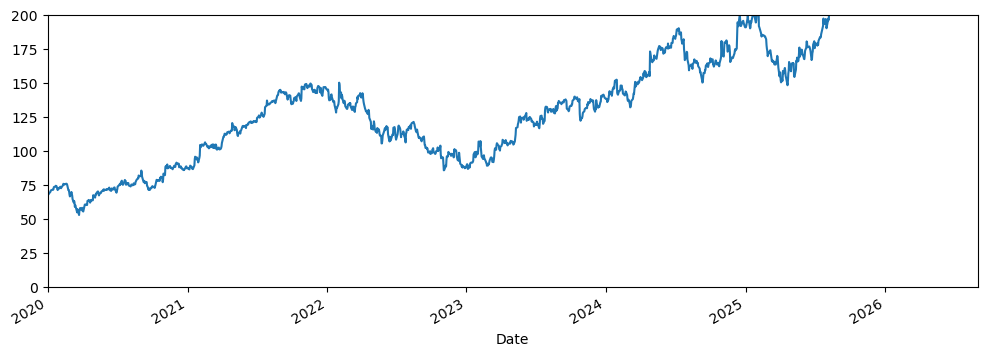

In [22]:
## xlimit and y limit
df['High'].plot(xlim=['2020-01-01','2026-09-01'],ylim=[0,200],figsize=(12,4))

<Axes: xlabel='Date'>

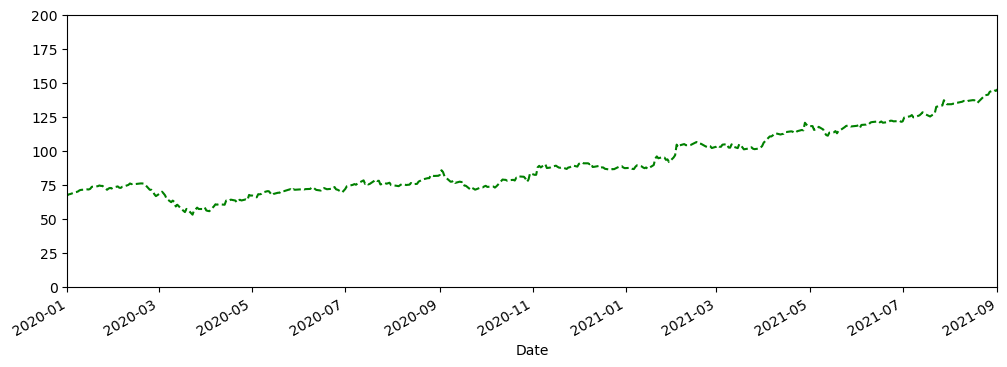

In [26]:
df['High'].plot(xlim=['2020-01-01','2021-09-01'],ylim=[0,200],figsize=(12,4),ls='--',c='green')

In [27]:
index=df.loc['2020-01-01':'2021-09-01'].index
share_open=df.loc['2020-01-01':'2021-09-01']['Open']

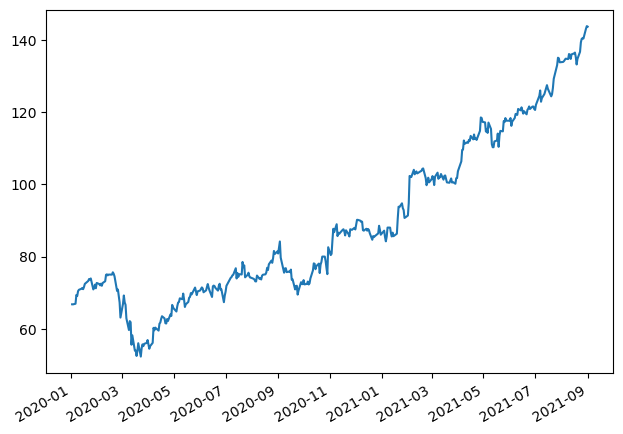

In [28]:
figure,axis=plt.subplots()
plt.tight_layout()
## Preventing overlapping
figure.autofmt_xdate()
axis.plot(index,share_open)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2432 entries, 2017-01-03 to 2026-09-04
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2432 non-null   float64
 1   High    2432 non-null   float64
 2   Low     2432 non-null   float64
 3   Open    2432 non-null   float64
 4   Volume  2432 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 178.5 KB


In [30]:
df = df.reset_index()

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2432 entries, 0 to 2431
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2432 non-null   datetime64[ns]
 1   Close   2432 non-null   float64       
 2   High    2432 non-null   float64       
 3   Low     2432 non-null   float64       
 4   Open    2432 non-null   float64       
 5   Volume  2432 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 114.1 KB


In [32]:
df = df.set_index('Date',drop=True)

In [33]:
df.sample(5)

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-11-08,177.106339,179.638545,176.838217,179.390288,22006200
2022-09-26,97.244659,98.938540,96.878152,97.175320,27072700
2023-09-06,133.192581,135.243061,132.410019,134.737874,18684500
2017-01-24,42.076118,42.174679,41.717032,41.949818,33768000
2020-05-18,68.606178,68.981604,67.071775,67.437300,47094000


In [34]:
df.resample(rule='YE').min()

Price,Close,High,Low,Open,Volume
Date,,,,,
2017-12-31,40.007797,40.189568,39.468929,39.653668,14538000
2018-12-31,48.769428,50.128989,48.422230,48.752091,14178000
2019-12-31,50.790195,52.005139,50.636658,50.875885,12802000
2020-12-31,52.209690,52.842667,49.968021,52.320634,9312000
2021-12-31,85.332001,86.376565,84.005625,84.211665,14302000
2022-12-31,82.643578,85.704447,82.554422,84.595016,9701400
2023-12-31,85.387482,86.744571,84.060112,85.169560,12514300
2024-12-31,130.161407,131.984083,129.438301,130.636902,10242100
2025-12-31,144.021332,148.251382,139.870908,140.886128,10097400


In [35]:
df.resample(rule='YE').max()

Price,Close,High,Low,Open,Volume
Date,,,,,
2017-12-31,53.743099,53.812439,53.108142,53.640578,118672000
2018-12-31,63.669140,63.963342,62.554744,63.848438,128220000
2019-12-31,67.481361,67.708217,67.012339,67.557150,133178000
2020-12-31,90.388390,91.322507,89.993652,90.168986,108358000
2021-12-31,148.426102,149.543469,147.495453,148.561798,97882000
2022-12-31,146.604950,150.118014,144.150810,149.824315,123200000
2023-12-31,140.186035,141.335089,139.859144,140.255377,119455000
2024-12-31,195.512466,200.244698,193.842274,196.099033,71910000
2025-12-31,322.601013,327.977016,318.342117,325.363817,127490100


In [42]:
df.resample(rule="YE").std()

Price,Close,High,Low,Open,Volume
Date,,,,,
2017-12-31,3.732846,3.787259,3.692800,3.740594,1.383847e+07
2018-12-31,3.446722,3.316926,3.542651,3.449740,1.731488e+07
2019-12-31,3.951964,3.916729,4.002819,3.943866,1.441882e+07
2020-12-31,8.675607,8.617372,8.823091,8.700270,1.818731e+07
2021-12-31,18.159177,18.178075,18.128091,18.255024,1.276469e+07
2022-12-31,15.957296,16.143850,15.802473,16.115544,1.361927e+07
2023-12-31,16.016083,16.076520,16.060481,16.118964,1.323258e+07
2024-12-31,15.372022,15.576733,15.199810,15.363691,1.129164e+07
2025-12-31,51.343891,51.858698,50.809207,51.432653,1.596408e+07


In [46]:
df.resample(rule="YE").sum()

Price,Close,High,Low,Open,Volume
Date,,,,,
2017-12-31,11682.980347,11750.661811,11601.484814,11679.021532,8118022000
2018-12-31,13948.913345,14109.529518,13791.053006,13955.388255,10270748000
2019-12-31,14867.855442,14973.943467,14743.556282,14854.884346,7625710000
2020-12-31,18532.909554,18753.965053,18289.975247,18516.323450,10108138000
2021-12-31,31009.593750,31266.819098,30712.289331,30989.788124,7689512000
2022-12-31,28533.338341,28961.844845,28145.641566,28563.003085,8726650100
2023-12-31,29418.740463,29725.739082,29076.249463,29357.691412,8182228100
2024-12-31,40939.891876,41349.673905,40523.831736,40919.162057,6918803600
2025-12-31,52530.703934,53146.994091,51858.548719,52502.311322,9064602400


<Axes: xlabel='Date'>

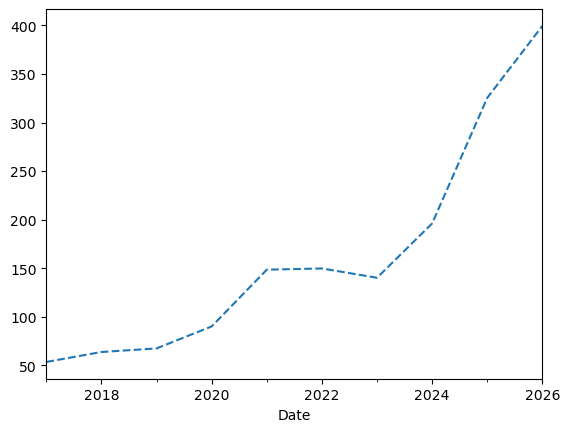

In [50]:
df.resample(rule='YE').max()['Open'].plot(ls="--")

<Axes: xlabel='Date'>

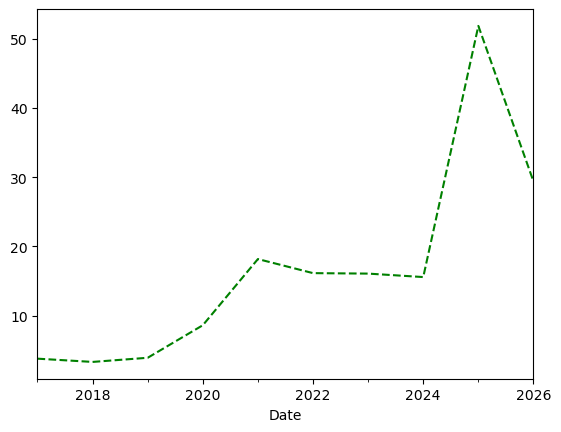

In [52]:
df.resample(rule="YE").std()["High"].plot(ls="--",color="green")

In [53]:
df['open:30 days rolling']=df['Open'].rolling(30).mean()

In [54]:
df.head(35)

Price,Close,High,Low,Open,Volume,open:30 days rolling
Date,,,,,,
2017-01-03,40.019688,40.189568,39.468929,39.653668,39180000,NaN
2017-01-04,40.007797,40.288131,39.826524,40.112797,30306000,NaN
2017-01-05,40.267826,40.303486,39.916173,39.994427,26810000,NaN
2017-01-06,40.871582,41.057315,40.192542,40.365397,40342000,NaN
2017-01-09,40.969162,41.130129,40.693782,40.929043,28178000,NaN
2017-01-10,40.911201,41.079601,40.769057,40.963703,23948000,NaN
2017-01-11,41.101887,41.103867,40.686343,40.941415,26508000,NaN
2017-01-12,41.085545,41.127644,40.663558,41.028584,26990000,NaN
2017-01-13,41.155380,41.339129,41.085050,41.158350,25804000,NaN
